# 01 — villages

**What this notebook does.** Turns the BushTel community list into the project spine:
one row per NT community (village), tagged with the ABS SA1 it sits inside and that SA1's
remoteness class. No people-side or infrastructure fact is attached here beyond geography —
later notebooks add columns to this table, never rows.

**What it reads** (raw / external only):

| dataframe | file | what it is |
|---|---|---|
| `bushtel_communities_gdf` | `data/raw/bushtel/Com_BushTel_Profile_CMC_2024.json` | 792 NT communities, points, EPSG:4326 |
| `sa1_polygons_gdf` | `data/external/abs_boundaries/SA1_2021_AUST_GDA2020_SHP/…shp` | NT SA1 polygons, EPSG:7844 |
| `ra_workbook_df` | `data/external/abs_boundaries/RA_2021_AUST.xlsx` | SA1 → Remoteness Area lookup |

**What it writes** (`data/processed/`):

| file | one row is | key | rows |
|---|---|---|---|
| `villages.csv` | one village | `community_id` | 792 |
| `villages.geojson` | same, as points (EPSG:4326) | `community_id` | 792 |

**Decisions carried in from the 00a EDA** (`PROJECT_CONTEXT.md` §11):
- **No duplicate `community_id`** — 792 features, 792 ids. We assert it; there is no dedupe step.
- `population_count` → **`population_count_bushtel`**, `population_source` → `population_source_bushtel`;
  kept for reference, **never used** as population anywhere downstream.
- **ILOC is dropped** — no `iloc_code` / `iloc_name`. SA1 is the only geography tag.
- **No census population column on `villages.csv`** — population is an SA1 fact and lives only
  on `sa1_report` (nb 02). It is deliberately never joined onto villages: one SA1 can hold dozens of
  villages and its census count can't be split between them. villages.csv carries `sa1_code`,
  `sa2_name`, `remoteness_name`, `is_remote`, `n_villages_in_sa1` only.
- `is_remote` = `remoteness_name` in {Remote, Very Remote} → `True`; Outer Regional → `False`.

Distances are not computed here. The spatial join is *point-in-polygon*, exact.

In [1]:
# Every import for the whole notebook lives in this cell.
%matplotlib inline
import json
import os
from pathlib import Path

# notebooks/ -> repo root, so the data/ paths below resolve
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)

In [2]:
# Every raw/external file the notebook needs is read here, one line each. Nothing is
# opened anywhere else below.

BUSHTEL_JSON = "data/raw/bushtel/Com_BushTel_Profile_CMC_2024.json"
SA1_SHP      = "data/external/abs_boundaries/SA1_2021_AUST_GDA2020_SHP/SA1_2021_AUST_GDA2020.shp"
RA_XLSX      = "data/external/abs_boundaries/RA_2021_AUST.xlsx"

# the SA1 shapefile is national; this WHERE clause makes GDAL return only NT rows
NT_WHERE = "STE_NAME21 = 'Northern Territory'"
# SA1 codes are 11-digit identifiers — always string, or joins fail silently
SA1_CODE_DTYPE = {"SA1_CODE_2021": str}

bushtel_communities_gdf = gpd.read_file(BUSHTEL_JSON)                        # 792 points, EPSG:4326
sa1_polygons_gdf        = gpd.read_file(SA1_SHP, where=NT_WHERE)             # NT SA1 polygons, EPSG:7844
ra_workbook_df          = pd.read_excel(RA_XLSX, sheet_name="SA1_RA_2021_AUST", dtype=SA1_CODE_DTYPE)

OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

EDA_PLOT_DIR = Path("docs/eda")
EDA_PLOT_DIR.mkdir(parents=True, exist_ok=True)
eda_figures = {}

print(f"bushtel_communities_gdf : {len(bushtel_communities_gdf)} rows, CRS {bushtel_communities_gdf.crs}")
print(f"sa1_polygons_gdf        : {len(sa1_polygons_gdf)} rows, CRS {sa1_polygons_gdf.crs}")
print(f"ra_workbook_df          : {len(ra_workbook_df)} rows (all AU)")

bushtel_communities_gdf : 792 rows, CRS EPSG:4326
sa1_polygons_gdf        : 649 rows, CRS EPSG:7844
ra_workbook_df          : 61845 rows (all AU)


## 1. Tidy the BushTel list into a village table

Keep BushTel's own identifiers and descriptive fields, with clearer names. `population_count`
and `population_source` are renamed with a `_bushtel` suffix to make it unmistakable that
they are BushTel's own figures — reference only, never summed as population.

In [3]:
# explicit column list — nothing derived from another frame
BUSHTEL_PASSTHROUGH = [
    "community_id", "community_name", "community_aliases", "community_type",
    "latitude", "longitude",
    "land_council", "local_govt_council", "ntg_region", "ward", "electorate",
    "main_language", "bushtel_url",
]

villages_df = bushtel_communities_gdf[BUSHTEL_PASSTHROUGH].copy()
villages_df["community_aliases"] = villages_df["community_aliases"].fillna("")  # kept raw; nb 06 handles the sentinel
villages_df["population_count_bushtel"]  = pd.to_numeric(
    bushtel_communities_gdf["population_count"], errors="coerce").astype("Int64")   # nullable: "no figure" != 0
villages_df["population_source_bushtel"] = bushtel_communities_gdf["population_source"]
villages_df["community_id"] = villages_df["community_id"].astype(int)
villages_df = villages_df.sort_values("community_id").reset_index(drop=True)

# --- guard: the key must be unique and the count exactly 792 (00a: there is NO duplicate) ---
assert villages_df["community_id"].is_unique, "community_id is not unique"
assert len(villages_df) == 792, f"expected 792 villages, got {len(villages_df)}"
print(f"{len(villages_df)} villages, community_id unique")
villages_df.head()

792 villages, community_id unique


,community_id,community_name,community_aliases,community_type,latitude,longitude,land_council,local_govt_council,ntg_region,ward,electorate,main_language,bushtel_url,population_count_bushtel,population_source_bushtel
0,1,ADELAIDE BORE,"WOOLA,WOOLLA",Family Outstation,-22.21485,133.93607,CENTRAL LAND COUNCIL,CENTRAL DESERT,CENTRAL AUSTRALIA,ANMATJERE,BARKLY,Not recorded,https://bushtel.nt.gov.au/profile/1,14,Homelands Service Provider Report 2023
1,2,ALYUEN,"AILERON,ALUM,ALUM CAMP",Family Outstation,-22.66949,133.35147,CENTRAL LAND COUNCIL,CENTRAL DESERT,CENTRAL AUSTRALIA,ANMATJERE,BARKLY,Not recorded,https://bushtel.nt.gov.au/profile/2,12,Homelands Service Provider Report 2023
2,3,AKNGWERTNARRE,MORRIS SOAK,Town Camp,-23.69280,133.86120,CENTRAL LAND COUNCIL,ALICE SPRINGS,CENTRAL AUSTRALIA,Not recorded,BRAITLING,Not recorded,https://bushtel.nt.gov.au/profile/3,<NA>,Not recorded
3,4,ALKIPI,"ALKIPIE,ALKPIE,MOUNT LARRY,YALKIPI",Family Outstation,-23.27356,131.82924,CENTRAL LAND COUNCIL,MACDONNELL,CENTRAL AUSTRALIA,LURITJA PINTUBI,GWOJA,Not recorded,https://bushtel.nt.gov.au/profile/4,<NA>,Not recorded
4,5,RED SANDHILL,INTJIRRANGA,Family Outstation,-24.00974,132.85279,CENTRAL LAND COUNCIL,MACDONNELL,CENTRAL AUSTRALIA,LJIRAPINTA,GWOJA,Not recorded,https://bushtel.nt.gov.au/profile/5,3,Homelands Service Provider Report 2023


### Validate: what the tidy table looks like

In [4]:
print("community_type:")
print(villages_df["community_type"].value_counts())
n_with_pop = int(villages_df["population_count_bushtel"].notna().sum())
print(f"\npopulation_count_bushtel present: {n_with_pop} / {len(villages_df)}  (reference only)")
print("population_source_bushtel:")
print(villages_df["population_source_bushtel"].value_counts(dropna=False))

community_type:
community_type
Family Outstation    630
Major                 59
Town Camp             45
Minor                 37
Village               13
Town                   7
City                   1
Name: count, dtype: int64

population_count_bushtel present: 457 / 792  (reference only)
population_source_bushtel:
population_source_bushtel
Homelands Service Provider Report 2023    379
Not recorded                              335
Based on ABS 2021 Census SA1               78
Name: count, dtype: int64


## 2. Which SA1 does each village sit inside?

Point-in-polygon join in **EPSG:7844** (the shapefile's own CRS — the village points are
reprojected to match). `predicate="within"` = the point is strictly inside the polygon.

In [5]:
# village points -> the shapefile's CRS
village_points_gdf = gpd.GeoDataFrame(
    villages_df.copy(),
    geometry=gpd.points_from_xy(villages_df["longitude"], villages_df["latitude"]),
    crs="EPSG:4326",
).to_crs(sa1_polygons_gdf.crs)

sa1_slim_gdf = sa1_polygons_gdf[["SA1_CODE21", "SA2_NAME21", "geometry"]].rename(
    columns={"SA1_CODE21": "sa1_code", "SA2_NAME21": "sa2_name"})

villages_tagged_gdf = gpd.sjoin(
    village_points_gdf, sa1_slim_gdf, how="left", predicate="within",
).drop(columns="index_right")

### Validate the SA1 join — counts, unmatched, fan-out

In [6]:
n_in  = len(village_points_gdf)
n_out = len(villages_tagged_gdf)
n_unmatched = int(villages_tagged_gdf["sa1_code"].isna().sum())
n_fanned = int(villages_tagged_gdf["community_id"].duplicated().sum())

print(f"rows in : {n_in}")
print(f"rows out: {n_out}")
print(f"villages with no SA1 match : {n_unmatched}")
print(f"villages matched to >1 SA1 : {n_fanned}")

assert n_unmatched == 0, "a village fell outside every NT SA1 polygon — investigate before writing"
assert n_out == n_in and n_fanned == 0, "the join changed the row count — a village is on a boundary"
print("\nOK: 1 row per village, every village inside exactly one SA1.")
print(f"distinct SA1s containing at least one village: {villages_tagged_gdf['sa1_code'].nunique()}")

rows in : 792
rows out: 792
villages with no SA1 match : 0
villages matched to >1 SA1 : 0

OK: 1 row per village, every village inside exactly one SA1.
distinct SA1s containing at least one village: 179


## 3. Attach the remoteness class

The SA1 → Remoteness Area workbook has one row per NT SA1. Merge it on `sa1_code`
(`validate="many_to_one"` — many villages share an SA1, each SA1 appears once in the workbook).

In [7]:
ra_nt_df = ra_workbook_df.loc[
    ra_workbook_df["STATE_NAME_2021"] == "Northern Territory",
    ["SA1_CODE_2021", "RA_NAME_2021"],
].rename(columns={"SA1_CODE_2021": "sa1_code", "RA_NAME_2021": "remoteness_name"})

villages_remoteness_df = pd.DataFrame(villages_tagged_gdf).merge(
    ra_nt_df, on="sa1_code", how="left", validate="many_to_one")

# is_remote: a plain flag for "this village is in Remote or Very Remote Australia".
# Outer Regional (NT = greater Darwin) -> False; Remote / Very Remote -> True.
REMOTE_CLASSES = ("Remote Australia", "Very Remote Australia")
villages_remoteness_df["is_remote"] = villages_remoteness_df["remoteness_name"].isin(REMOTE_CLASSES)

### Validate the remoteness merge

In [8]:
missing_in_ra = sorted(set(villages_tagged_gdf["sa1_code"]) - set(ra_nt_df["sa1_code"]))
print(f"village SA1 codes not found in the RA workbook: {len(missing_in_ra)} {missing_in_ra}")
print(f"villages with no remoteness_name after merge : {int(villages_remoteness_df['remoteness_name'].isna().sum())}")
assert villages_remoteness_df["remoteness_name"].notna().all(), "a village SA1 has no remoteness class"

print("\nvillages by remoteness class:")
print(villages_remoteness_df["remoteness_name"].value_counts())
print("\nis_remote against remoteness_name (check the mapping):")
print(pd.crosstab(villages_remoteness_df["remoteness_name"], villages_remoteness_df["is_remote"]))
print("\n-> as 00a flagged: the remote-community story is almost entirely Remote + Very Remote "
      f"({int(villages_remoteness_df['is_remote'].sum())} of {len(villages_remoteness_df)} villages).")

village SA1 codes not found in the RA workbook: 0 []
villages with no remoteness_name after merge : 0

villages by remoteness class:
remoteness_name
Very Remote Australia       673
Remote Australia            106
Outer Regional Australia     13
Name: count, dtype: int64

is_remote against remoteness_name (check the mapping):
is_remote                 False  True 
remoteness_name                       
Outer Regional Australia     13      0
Remote Australia              0    106
Very Remote Australia         0    673

-> as 00a flagged: the remote-community story is almost entirely Remote + Very Remote (779 of 792 villages).


## 4. How many villages share each SA1?

`n_villages_in_sa1` is a structural count (not a population). It matters because one SA1 can
hold 30+ outstations over tens of thousands of km² — a single tower there does not cover them all.

In [9]:
villages_remoteness_df["n_villages_in_sa1"] = (
    villages_remoteness_df.groupby("sa1_code")["community_id"].transform("count"))

### Validate: spot-check 3 SA1s by eye, then the distribution

SA1s holding the most villages:
sa1_code     sa2_name           
70201105312  Tanami                 44
70203106107  West Arnhem            43
70203106104  West Arnhem            35
70201105216  Sandover - Plenty      34
70201105013  Petermann - Simpson    34
70205106602  Gulf                   31
70202105503  Barkly                 30
70204106310  East Arnhem            24
Name: community_id, dtype: int64

SA1 70201105312  (Tanami)  n_villages_in_sa1 says 44, actual rows 44
   ALKNGARRIINTJA, ARMSTRONGS, ARRKAPA, CAMELS HUMP, EIGHT MILE, FIVE MILE, GILBERT SPRINGS, ILKARRALALAMA, IMPORTNA, INTJARTNAMA, IPALALA, IPOLERA, KAPORILYA, KATJUTARI, KULPITHARRA, KWALA, LABRAPUNTJA, LILTJERA, LTIRA, LUNTHARRA, LYILYALANAMA, MBALKANAKA, MBUNGHARA, MERRAL NTARRAKALA, MORRIS GAP, MOTNAS, NATJITNAMA, NTAKARRA, OLD STATION, PALM PADDOCK, RARANGANTJUTA, RED SANDHILL, RODNA, RUTJINGKA, SUGAR CREEK, TJAMANGKURRA, TNAWURTA, TNYIMIPURTA, ULPUNDA, UNDURANA 1C, UNDURANA 2A, WEST WATERHOUSE, YAKALA, YATEMA

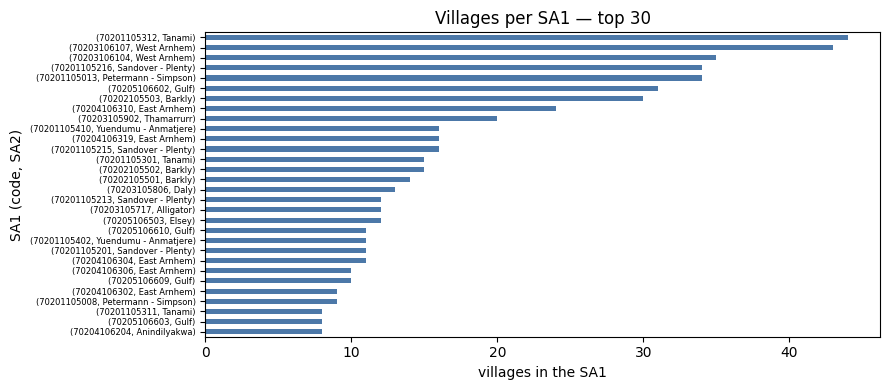

In [10]:
busy_sa1s = (villages_remoteness_df.groupby(["sa1_code", "sa2_name"])["community_id"]
             .count().sort_values(ascending=False))
print("SA1s holding the most villages:")
print(busy_sa1s.head(8))

for code in busy_sa1s.head(3).index.get_level_values("sa1_code"):
    rows = villages_remoteness_df[villages_remoteness_df["sa1_code"] == code]
    print(f"\nSA1 {code}  ({rows['sa2_name'].iloc[0]})  "
          f"n_villages_in_sa1 says {rows['n_villages_in_sa1'].iloc[0]}, "
          f"actual rows {len(rows)}")
    print("   " + ", ".join(sorted(rows["community_name"])))

fig, ax = plt.subplots(figsize=(9, 4))
busy_sa1s.head(30).iloc[::-1].plot.barh(ax=ax, color="#4c78a8")
ax.set_xlabel("villages in the SA1"); ax.set_ylabel("SA1 (code, SA2)")
ax.set_title("Villages per SA1 — top 30")
ax.tick_params(axis="y", labelsize=6)
fig.tight_layout()
eda_figures["01_villages_per_sa1_bar"] = fig

## 5. Assemble `villages.csv`

Column list written out **explicitly** (never derived from another frame — that bug dropped
`sa1_code` last session). ILOC columns and any census population column are deliberately absent.

In [11]:
VILLAGE_OUT_COLUMNS = [
    "community_id", "community_name", "community_aliases", "community_type",
    "latitude", "longitude",
    "land_council", "local_govt_council", "ntg_region", "ward", "electorate",
    "main_language", "bushtel_url",
    "population_count_bushtel", "population_source_bushtel",
    "sa1_code", "sa2_name", "remoteness_name", "is_remote", "n_villages_in_sa1",
]
villages_out_df = (villages_remoteness_df[VILLAGE_OUT_COLUMNS]
                   .sort_values("community_id").reset_index(drop=True))

# --- guards before anything is written ---
assert list(villages_out_df.columns) == VILLAGE_OUT_COLUMNS, "column set / order changed"
assert len(villages_out_df) == 792, f"expected 792 rows, got {len(villages_out_df)}"
assert villages_out_df["community_id"].is_unique, "community_id not unique in output"
assert villages_out_df[["sa1_code", "sa2_name", "remoteness_name"]].notna().all().all(), "a geography tag is null"
villages_out_df.head()

,community_id,community_name,community_aliases,community_type,latitude,longitude,land_council,local_govt_council,ntg_region,ward,electorate,main_language,bushtel_url,population_count_bushtel,population_source_bushtel,sa1_code,sa2_name,remoteness_name,is_remote,n_villages_in_sa1
0,1,ADELAIDE BORE,"WOOLA,WOOLLA",Family Outstation,-22.21485,133.93607,CENTRAL LAND COUNCIL,CENTRAL DESERT,CENTRAL AUSTRALIA,ANMATJERE,BARKLY,Not recorded,https://bushtel.nt.gov.au/profile/1,14,Homelands Service Provider Report 2023,70201105410,Yuendumu - Anmatjere,Very Remote Australia,True,16
1,2,ALYUEN,"AILERON,ALUM,ALUM CAMP",Family Outstation,-22.66949,133.35147,CENTRAL LAND COUNCIL,CENTRAL DESERT,CENTRAL AUSTRALIA,ANMATJERE,BARKLY,Not recorded,https://bushtel.nt.gov.au/profile/2,12,Homelands Service Provider Report 2023,70201105410,Yuendumu - Anmatjere,Very Remote Australia,True,16
2,3,AKNGWERTNARRE,MORRIS SOAK,Town Camp,-23.69280,133.86120,CENTRAL LAND COUNCIL,ALICE SPRINGS,CENTRAL AUSTRALIA,Not recorded,BRAITLING,Not recorded,https://bushtel.nt.gov.au/profile/3,<NA>,Not recorded,70201104513,Charles,Remote Australia,True,2
3,4,ALKIPI,"ALKIPIE,ALKPIE,MOUNT LARRY,YALKIPI",Family Outstation,-23.27356,131.82924,CENTRAL LAND COUNCIL,MACDONNELL,CENTRAL AUSTRALIA,LURITJA PINTUBI,GWOJA,Not recorded,https://bushtel.nt.gov.au/profile/4,<NA>,Not recorded,70201105310,Tanami,Very Remote Australia,True,6
4,5,RED SANDHILL,INTJIRRANGA,Family Outstation,-24.00974,132.85279,CENTRAL LAND COUNCIL,MACDONNELL,CENTRAL AUSTRALIA,LJIRAPINTA,GWOJA,Not recorded,https://bushtel.nt.gov.au/profile/5,3,Homelands Service Provider Report 2023,70201105312,Tanami,Very Remote Australia,True,44


## 6. Validation maps

Villages coloured by `sa1_code` on top of the SA1 boundaries — the point colours should
change exactly where the polygons do. (Too many SA1s for a legend; this is a shape check,
not a lookup.) ILOC maps and the SA1-vs-ILOC region check from the old notebook are gone
because ILOC was dropped.

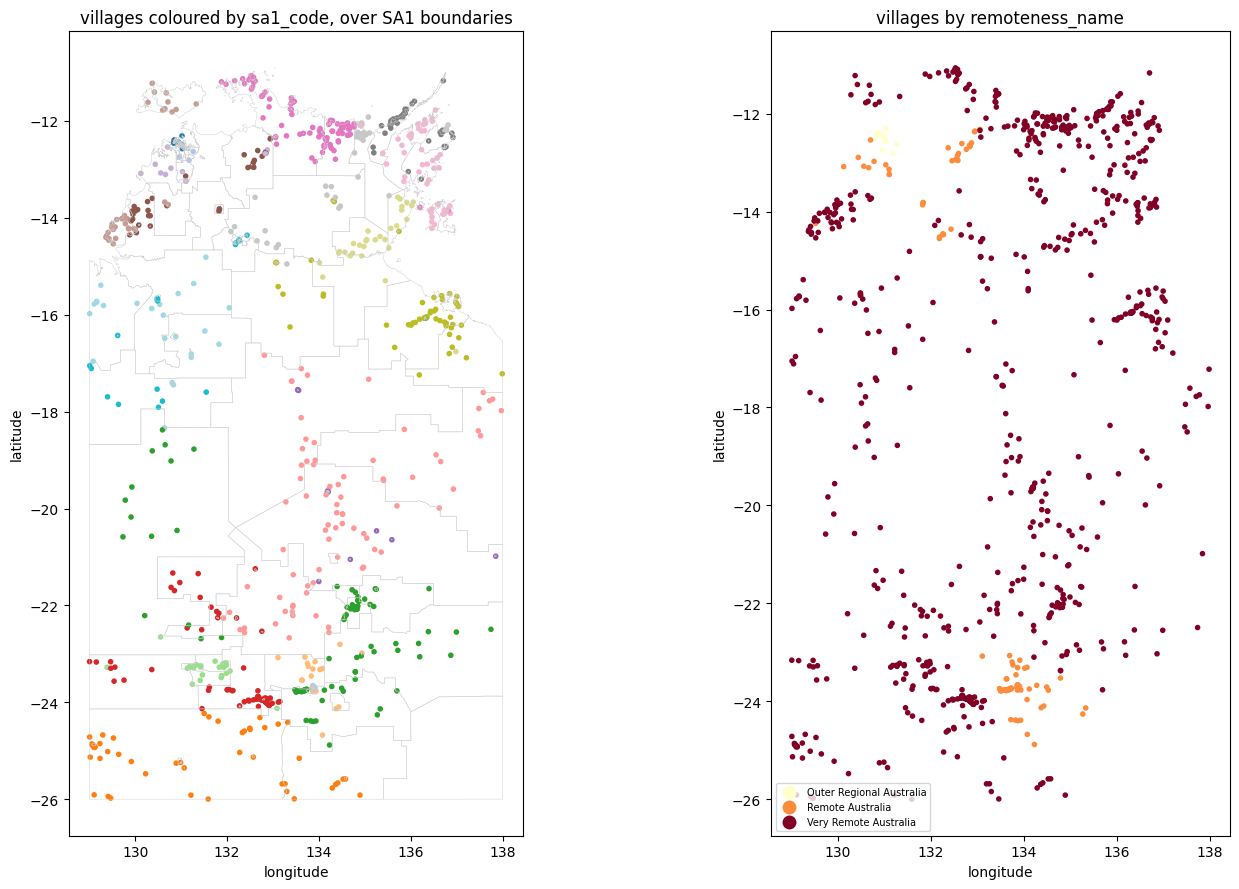

In [12]:
villages_geo_4326 = gpd.GeoDataFrame(
    villages_out_df.copy(),
    geometry=gpd.points_from_xy(villages_out_df["longitude"], villages_out_df["latitude"]),
    crs="EPSG:4326",
)
sa1_bounds_4326 = sa1_polygons_gdf.dropna(subset=["geometry"]).to_crs("EPSG:4326")

fig, axes = plt.subplots(1, 2, figsize=(15, 9))
sa1_bounds_4326.boundary.plot(ax=axes[0], color="0.8", linewidth=0.3)
villages_geo_4326.plot(ax=axes[0], column="sa1_code", cmap="tab20", markersize=9, legend=False)
axes[0].set_title("villages coloured by sa1_code, over SA1 boundaries")
axes[0].set_xlabel("longitude"); axes[0].set_ylabel("latitude")

villages_geo_4326.plot(ax=axes[1], column="remoteness_name", cmap="YlOrRd", markersize=9,
                       legend=True, legend_kwds={"fontsize": 7, "loc": "lower left"})
axes[1].set_title("villages by remoteness_name")
axes[1].set_xlabel("longitude"); axes[1].set_ylabel("latitude")
fig.tight_layout()
eda_figures["01_villages_by_sa1_map"] = fig

In [13]:
# Second-to-last cell: summary print.
print("01_villages — summary")
print("-" * 60)
print(f"rows in  : 792 BushTel communities")
print(f"rows out : {len(villages_out_df)}  (villages.csv, one per community_id)")
print(f"dropped  : 0  |  unmatched in SA1 join: 0  |  boundary fan-out: 0")
print(f"columns  : {len(VILLAGE_OUT_COLUMNS)}  (no iloc_*, no census population — SA1 is the unit for population)")
print(f"SA1s with >=1 village : {villages_out_df['sa1_code'].nunique()}")
print("remoteness:", villages_out_df["remoteness_name"].value_counts().to_dict())
print("asserts passed: key unique(2x), 792 rows, 0 unmatched, 0 fan-out, columns fixed, geography non-null")

01_villages — summary
------------------------------------------------------------
rows in  : 792 BushTel communities
rows out : 792  (villages.csv, one per community_id)
dropped  : 0  |  unmatched in SA1 join: 0  |  boundary fan-out: 0
columns  : 20  (no iloc_*, no census population — SA1 is the unit for population)
SA1s with >=1 village : 179
remoteness: {'Very Remote Australia': 673, 'Remote Australia': 106, 'Outer Regional Australia': 13}
asserts passed: key unique(2x), 792 rows, 0 unmatched, 0 fan-out, columns fixed, geography non-null


In [14]:
# Last cell: every file write in the notebook.
csv_path     = OUT_DIR / "villages.csv"
geojson_path = OUT_DIR / "villages.geojson"

villages_out_df.to_csv(csv_path, index=False)
gpd.GeoDataFrame(
    villages_out_df.copy(),
    geometry=gpd.points_from_xy(villages_out_df["longitude"], villages_out_df["latitude"]),
    crs="EPSG:4326",
).to_file(geojson_path, driver="GeoJSON")

for name, fig in eda_figures.items():
    fig.savefig(EDA_PLOT_DIR / f"{name}.png", dpi=120, bbox_inches="tight")

print("wrote:")
print(" ", csv_path, f"({len(villages_out_df)} rows)")
print(" ", geojson_path)
for name in eda_figures:
    print("  docs/eda/" + name + ".png")

wrote:
  data\processed\villages.csv (792 rows)
  data\processed\villages.geojson
  docs/eda/01_villages_per_sa1_bar.png
  docs/eda/01_villages_by_sa1_map.png
